# 03 - Concept Bottleneck and Local Attribution Audit

This notebook consolidates the concept-level part of the explainability study and the quantitative audit of the maintained local attribution methods.

Technical scope:

1. **Concept Bottleneck evaluation**  
   Compare the direct ResNet classifier with a model whose class prediction is mediated by AwA2 semantic concepts.
2. **Local attribution audit**  
   Summarize faithfulness, stability, class-discriminativeness and region-allocation diagnostics for Grad-CAM and Integrated Gradients.

The notebook is restricted to experimental analysis. Static blog/report generation is intentionally excluded from this notebook.


In [1]:
from pathlib import Path
from IPython.display import Image, display
import csv
import subprocess
import sys

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src").exists() and (candidate / "scripts").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the project root containing src/ and scripts/.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

MANIFEST = PROJECT_ROOT / "data" / "AWA2_subset_background20" / "awa2_manifest_subset.csv"
METADATA_ROOT = PROJECT_ROOT / "data" / "AWA2"
CHECKPOINT = PROJECT_ROOT / "outputs" / "checkpoints" / "best_resnet50_awa2.pt"

print("project_root:", PROJECT_ROOT)
print("manifest:", MANIFEST, "exists=", MANIFEST.exists())
print("checkpoint:", CHECKPOINT, "exists=", CHECKPOINT.exists())

RUN_CBM = False  # set True to retrain and regenerate CBM outputs
RUN_SANITY = False
RUN_ADVANCED_ATTRIBUTION_AUDIT = False


project_root: /home/emma/DeepLearning/Deep_Learning_XAI
manifest: /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv exists= True
checkpoint: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/checkpoints/best_resnet50_awa2.pt exists= True


## Explainability Scope

This notebook evaluates two explanation paradigms that go beyond raw heatmaps:

- **Concept Bottleneck Models** make concepts part of the prediction path. The class head receives predicted semantic attributes rather than arbitrary hidden features.
- **Sanity checks** evaluate whether saliency maps are stable, perturbation-consistent and dependent on learned model parameters.

The focus is on explanation reliability. Accuracy remains important, but it is interpreted together with concept quality, agreement with the baseline and saliency robustness metrics.


## 1. Concept Bottleneck Model

A Concept Bottleneck Model changes the prediction pipeline:

```text
image -> predicted concepts -> class
```

Unlike TCAV, this is not only post-hoc. Concepts become part of the model's decision path. This makes predictions easier to inspect and intervene on, but it may reduce accuracy because the model can no longer use arbitrary hidden features.

In this project, the concept targets come from AwA2 class-level attributes. That means every image of a class receives the same concept target. This is useful for an audit, but weaker than image-level concept annotation.

The notebook also inspects a **concept confusion matrix**. For every bottleneck concept, the script counts true positives, false positives, false negatives and true negatives after thresholding predicted concept probabilities. This identifies which semantic concepts are reliable and which ones are systematically confused.

Three class accuracies separate different failure sources: the direct ResNet accuracy, the normal CBM accuracy using image-predicted concepts, and the oracle-concept accuracy obtained by feeding the class head the AwA2 target vector. The oracle-minus-CBM gap estimates how much class performance is lost in `image -> concepts`; a low oracle accuracy instead indicates that the selected concept vocabulary or class head is insufficient.

Interventions are reported in two explicitly different forms. **Image-specific corrections** start from the actual concept prediction for one image and replace one coordinate with its AwA2 target. **Oracle-prototype sensitivity** starts from a class-level attribute prototype and only probes the concept-to-class head; it must not be interpreted as correcting a real image prediction.


CBM run skipped

 /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase8_cbm_summary_notebook.csv
rows: 1
{'num_classes': '20', 'num_concepts': '20', 'epochs': '5', 'concept_loss_weight': '1.0', 'class_loss_weight': '1.0', 'test_loss': '2.6778007993762123', 'test_class_loss': '2.1670571205599996', 'test_concept_loss': '0.5107436972176469', 'test_class_acc': '0.8053691275167785', 'test_concept_mae': '0.20511091123491326', 'test_concept_binary_acc': '0.7537751677852349', 'baseline_accuracy': '0.8573825503355704', 'cbm_baseline_agreement': '0.7348993288590604', 'baseline_evaluated_samples': '596'}

 /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase8_concept_metrics_notebook.csv
rows: 20
{'concept': 'stripes', 'mae': '0.17035022377967834', 'binary_accuracy': '0.8053691275167785', 'pearson': '0.6210169792175293', 'target_mean': '0.10082728415727615', 'prediction_mean': '0.26669982075691223'}
{'concept': 'furry', 'mae': '0.2990611493587494', 'binary_accuracy': '0.6459

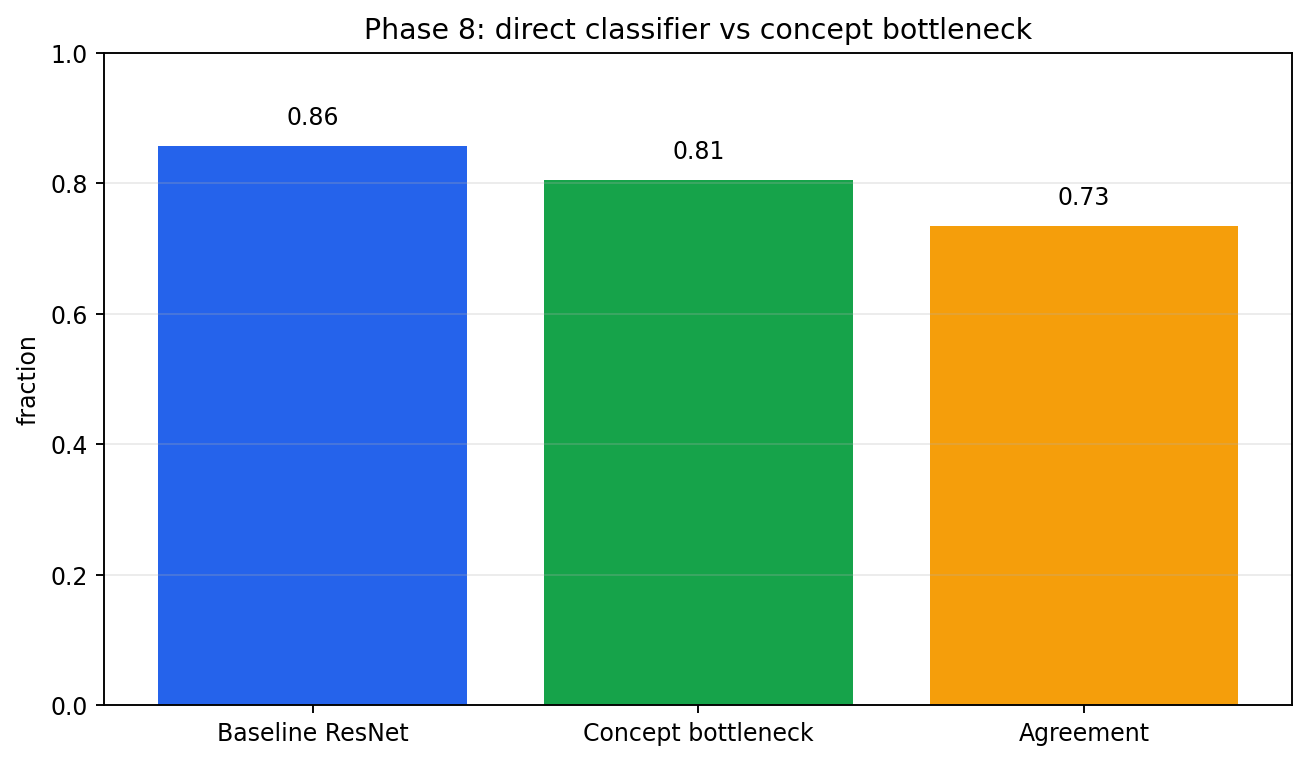

/home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase8_cbm_training_notebook.png


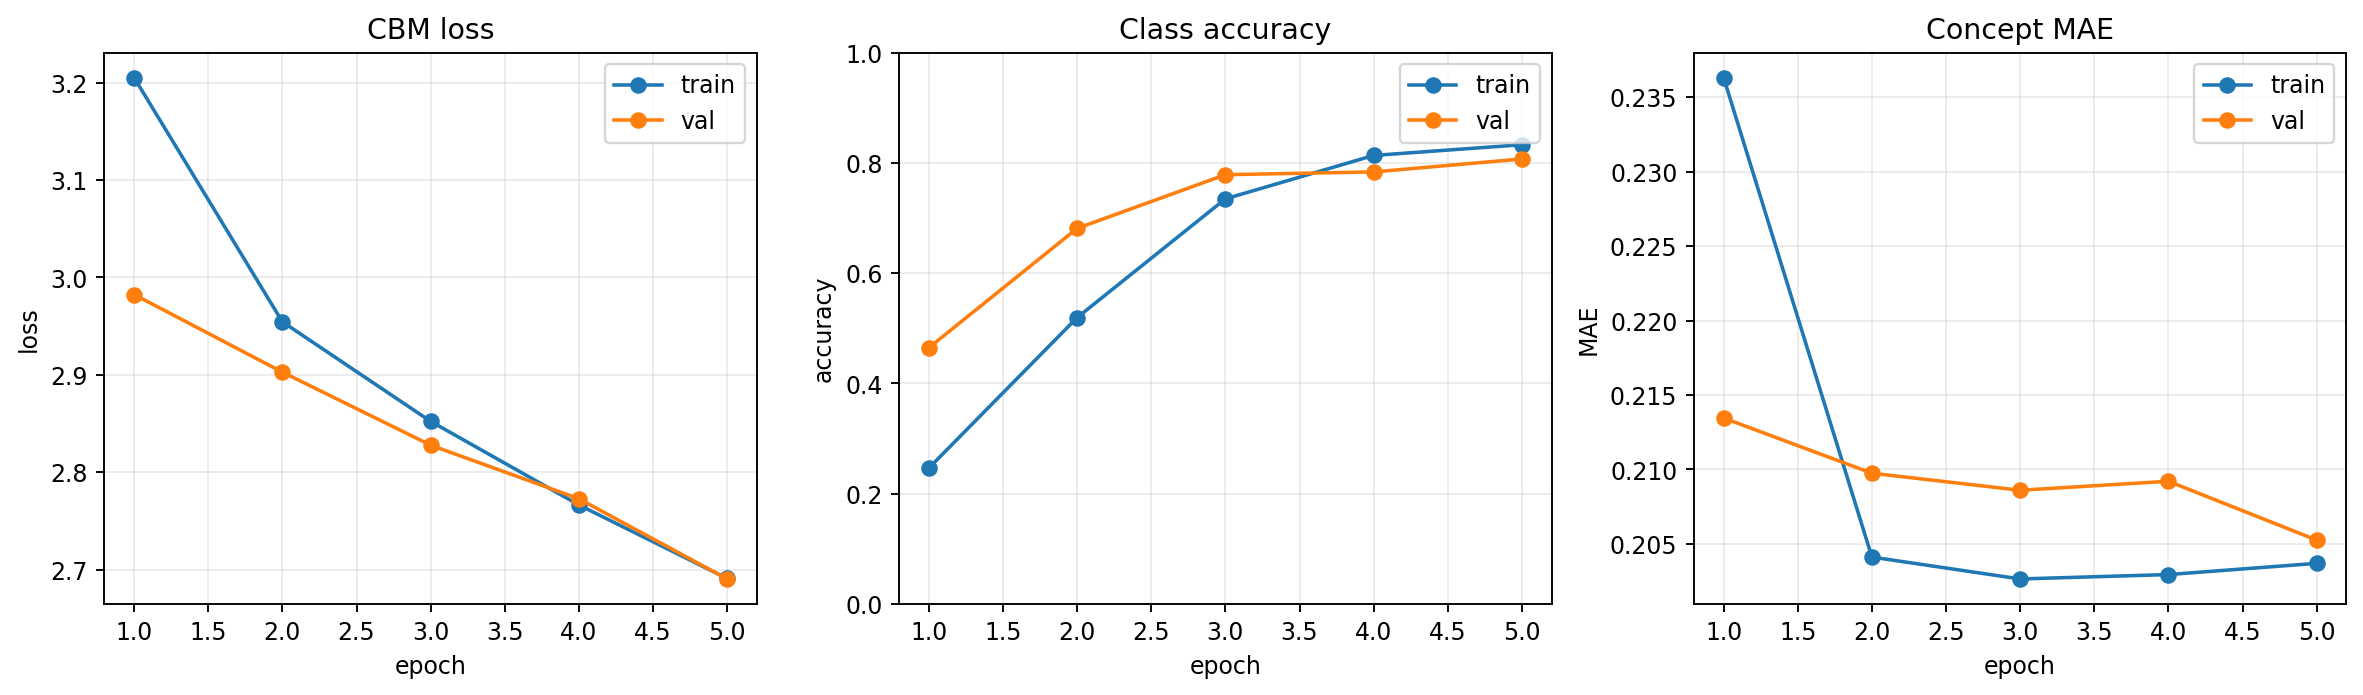

/home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase8_concept_prediction_metrics_notebook.png


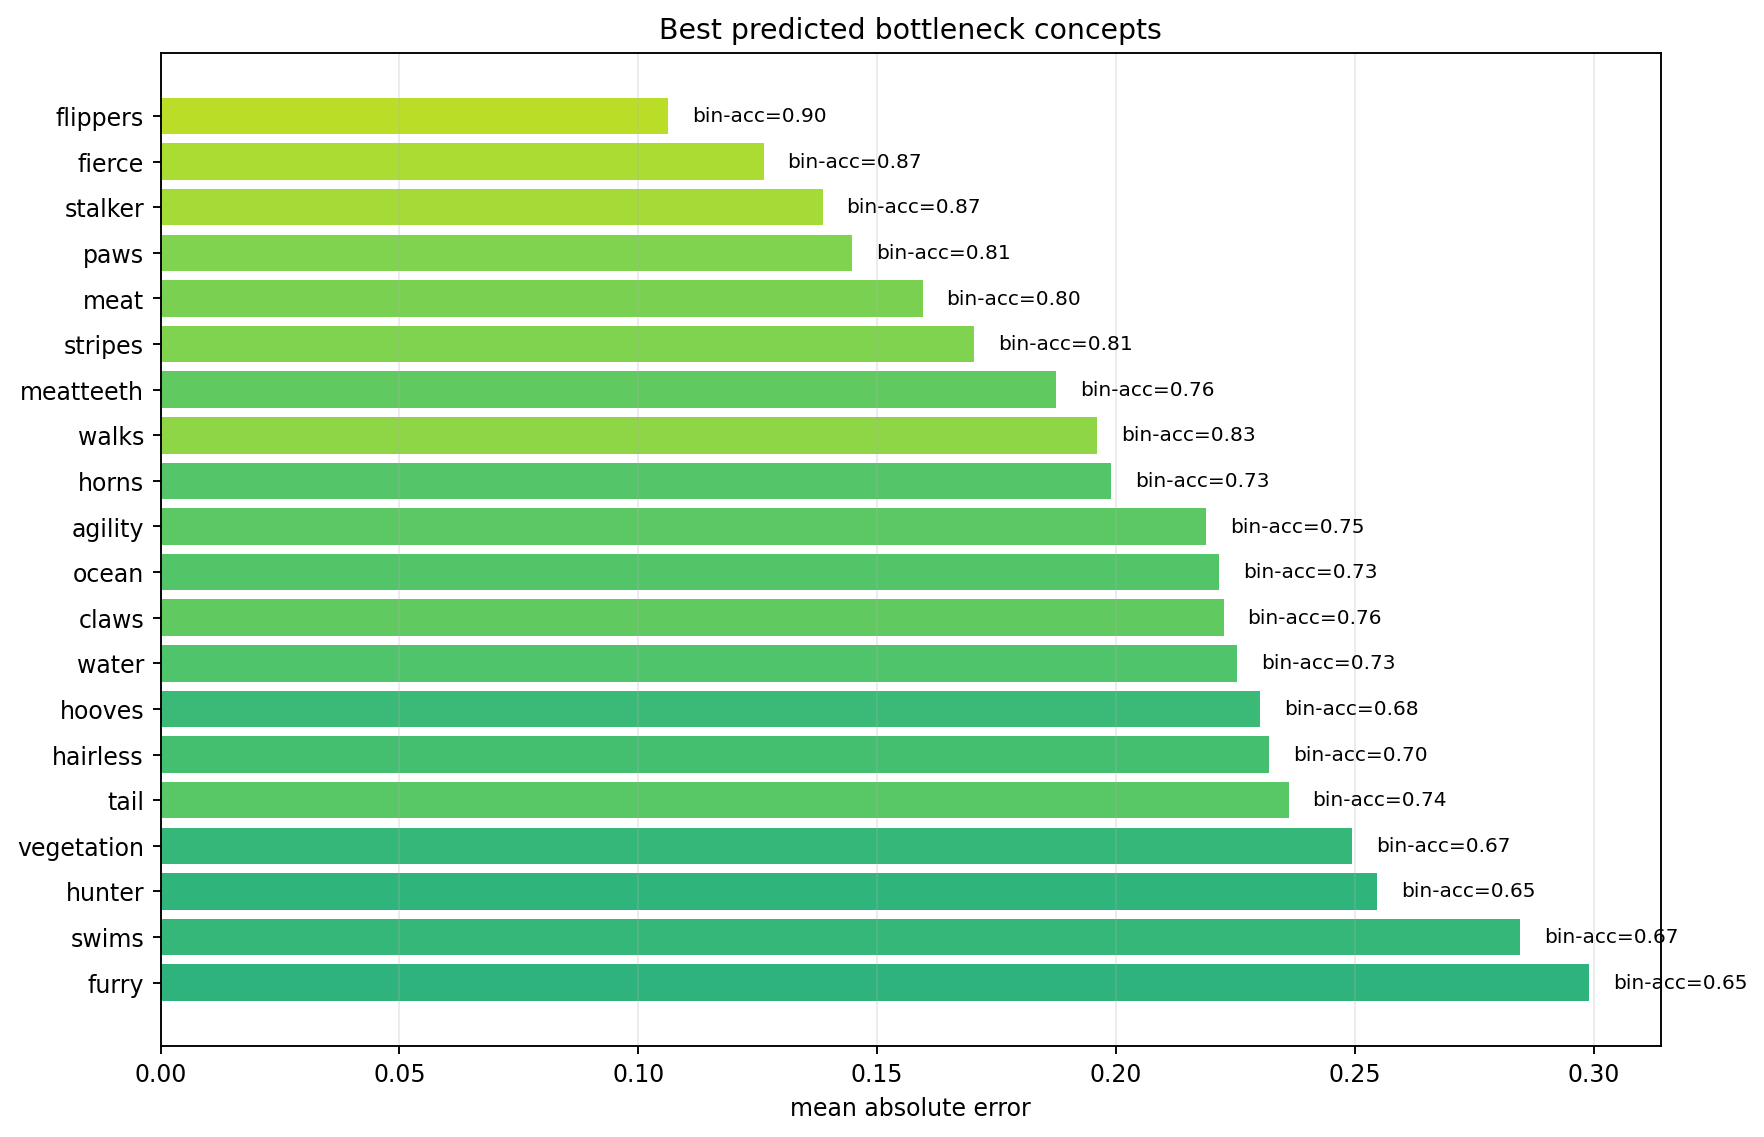

/home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase8_concept_confusion_matrix_notebook.png
missing
/home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase8_oracle_prototype_interventions_notebook.png
missing
/home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase8_image_concept_interventions_notebook.png
missing
/home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase8_cbm_error_analysis_notebook.png
missing


In [2]:
if RUN_CBM:
    cmd = [
        sys.executable,
        str(PROJECT_ROOT / 'scripts' / 'experiments' / 'train_cbm.py'),
        '--manifest', str(MANIFEST),
        '--metadata-root', str(METADATA_ROOT),
        '--backbone-checkpoint', str(CHECKPOINT),
        '--checkpoint-path', str(PROJECT_ROOT / 'outputs' / 'checkpoints' / 'phase8_cbm_notebook.pt'),
        '--history-output', str(PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_cbm_history_notebook.csv'),
        '--summary-output', str(PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_cbm_summary_notebook.csv'),
        '--concept-metrics-output', str(PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_concept_metrics_notebook.csv'),
        '--concept-confusion-output', str(PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_concept_confusion_matrix_notebook.csv'),
        '--predictions-output', str(PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_cbm_predictions_notebook.csv'),
        '--error-analysis-output', str(PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_cbm_error_analysis_notebook.csv'),
        '--error-summary-output', str(PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_cbm_error_summary_notebook.csv'),
        '--intervention-output', str(PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_oracle_prototype_interventions_notebook.csv'),
        '--image-intervention-output', str(PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_image_concept_interventions_notebook.csv'),
        '--training-figure-output', str(PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_cbm_training_notebook.png'),
        '--summary-figure-output', str(PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_cbm_summary_notebook.png'),
        '--concept-figure-output', str(PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_concept_prediction_metrics_notebook.png'),
        '--concept-confusion-figure-output', str(PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_concept_confusion_matrix_notebook.png'),
        '--intervention-figure-output', str(PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_oracle_prototype_interventions_notebook.png'),
        '--image-intervention-figure-output', str(PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_image_concept_interventions_notebook.png'),
        '--error-figure-output', str(PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_cbm_error_analysis_notebook.png'),
        '--top-concepts', '20',
        '--epochs', '5',
    ]
    print(' '.join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
else:
    print('CBM run skipped')

for csv_path in [
    PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_cbm_summary_notebook.csv',
    PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_concept_metrics_notebook.csv',
    PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_concept_confusion_matrix_notebook.csv',
    PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_image_concept_interventions_notebook.csv',
]:
    print('\n', csv_path)
    if csv_path.exists():
        with csv_path.open('r', newline='', encoding='utf-8') as handle:
            rows = list(csv.DictReader(handle))
        print('rows:', len(rows))
        for row in rows[:8]:
            print(row)
    else:
        print('missing')

for figure in [
    PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_cbm_summary_notebook.png',
    PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_cbm_training_notebook.png',
    PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_concept_prediction_metrics_notebook.png',
    PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_concept_confusion_matrix_notebook.png',
    PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_oracle_prototype_interventions_notebook.png',
    PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_image_concept_interventions_notebook.png',
    PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_cbm_error_analysis_notebook.png',
]:
    print(figure)
    if figure.exists():
        display(Image(filename=str(figure)))
    else:
        print('missing')


### Concept Bottleneck Result Interpretation

The Concept Bottleneck Model should be evaluated with six quantities:

- **CBM accuracy**: predictive performance after forcing the decision through concepts.
- **Baseline agreement**: fraction of predictions matching the direct ResNet classifier.
- **Concept prediction error**: quality of the intermediate semantic representation.
- **Concept confusion matrix**: per-concept TP/FP/FN/TN counts after thresholding predicted concept probabilities.
- **Class head on oracle concepts**: accuracy after replacing predicted concepts with the class-level AwA2 concept targets. Because the class head is trained on predicted concept vectors, this is an intervention stress test rather than a guaranteed upper bound.
- **Image-specific intervention effect**: change in the true-class probability when one predicted concept is corrected to its AwA2 target.

A competitive CBM indicates that selected concepts preserve relevant information. A performance drop can arise because the direct model uses information outside the vocabulary, the class-level targets are too coarse, or the image-to-concept head predicts them poorly. If oracle-concept accuracy is lower than predicted-concept CBM accuracy, the class head does not transfer cleanly to exact class prototypes; this indicates a concept-distribution mismatch and must not be interpreted as evidence that correct concepts reduce predictive information.


In [ ]:
summary_path = PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_cbm_summary_notebook.csv'
confusion_path = PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_concept_confusion_matrix_notebook.csv'
if summary_path.exists():
    with summary_path.open('r', newline='', encoding='utf-8') as handle:
        summary = next(csv.DictReader(handle))
    required_fields = {
        'test_class_acc',
        'baseline_accuracy',
        'cbm_baseline_agreement',
        'test_concept_mae',
        'test_concept_binary_acc',
        'backbone_source',
    }
    missing_fields = sorted(required_fields.difference(summary))
    if missing_fields:
        raise ValueError(f'CBM summary has an incompatible schema; missing columns: {missing_fields}')

    print('CBM accuracy:', float(summary['test_class_acc']))
    print('Baseline accuracy:', float(summary['baseline_accuracy']))
    print('CBM / baseline agreement:', float(summary['cbm_baseline_agreement']))
    print('Concept MAE:', float(summary['test_concept_mae']))
    print('Concept binary accuracy:', float(summary['test_concept_binary_acc']))
    print('Backbone source:', summary['backbone_source'])

    oracle_fields = {'oracle_concept_class_accuracy', 'oracle_minus_predicted_cbm_accuracy'}
    if oracle_fields.issubset(summary):
        oracle_accuracy = float(summary['oracle_concept_class_accuracy'])
        oracle_gap = float(summary['oracle_minus_predicted_cbm_accuracy'])
        print('Class head on oracle concepts:', oracle_accuracy)
        print('Oracle-input minus predicted-concept accuracy:', oracle_gap)
        if oracle_gap < 0:
            print(
                'Interpretation: the class head performs worse on exact AwA2 targets than on '
                'predicted concepts. Treat this as concept-distribution mismatch, not as an '
                'oracle upper bound.'
            )
    else:
        print('Legacy summary: oracle-intervention columns are unavailable. Rerun CBM training.')
else:
    print('missing:', summary_path)

if confusion_path.exists():
    with confusion_path.open('r', newline='', encoding='utf-8') as handle:
        confusion_rows = list(csv.DictReader(handle))
    confusion_rows = sorted(confusion_rows, key=lambda row: float(row['f1']))
    print('\nLowest-F1 bottleneck concepts:')
    for row in confusion_rows[:10]:
        print({
            'concept': row['concept'],
            'f1': round(float(row['f1']), 4),
            'precision': round(float(row['precision']), 4),
            'recall': round(float(row['recall']), 4),
            'tp': int(row['true_positive']),
            'fp': int(row['false_positive']),
            'fn': int(row['false_negative']),
            'tn': int(row['true_negative']),
        })
else:
    print('missing:', confusion_path)


### Interpretation checkpoint

The current CBM result is strong but not perfect: it is less accurate than the direct ResNet, yet still competitive. This is the trade-off the project should emphasize: interpretability improves, but the concept bottleneck can lose information and concept predictions can be noisy.


## 2. Local Attribution Robustness Checks

The local attribution audit evaluates whether Grad-CAM and Integrated Gradients remain stable and informative when the image or target class changes.

Diagnostics:

- **Sensitivity to small noise**: recompute the saliency map after a small input perturbation and compare Top-20% IoU plus Spearman correlation.
- **Deletion and insertion curves**: remove or restore the most salient pixels first and measure the target probability curve.
- **Class-discriminativeness**: compare maps for top-1 and top-2 predicted classes on the same image.
- **Region allocation**: estimate how much saliency lies on the approximate animal region versus the approximate background.


In [ ]:
ADVANCED_REPORT = PROJECT_ROOT / 'outputs' / 'reports' / 'advanced_attribution_audit_notebook.csv'
ADVANCED_SUMMARY = PROJECT_ROOT / 'outputs' / 'reports' / 'advanced_attribution_audit_notebook_summary.csv'
ADVANCED_FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'advanced_attribution_audit_notebook'
XAI_METHODS = ['gradcam', 'integrated_gradients']

if RUN_ADVANCED_ATTRIBUTION_AUDIT:
    cmd = [
        sys.executable,
        str(PROJECT_ROOT / 'scripts' / 'audits' / 'run_advanced_attribution_audit.py'),
        '--manifest', str(MANIFEST),
        '--checkpoint', str(CHECKPOINT),
        '--methods', *XAI_METHODS,
        '--num-examples', '4',
        '--batch-size', '16',
        '--ig-steps', '16',
        '--ig-internal-batch-size', '4',
        '--curve-steps', '10',
        '--report-output', str(ADVANCED_REPORT),
        '--summary-output', str(ADVANCED_SUMMARY),
        '--figure-dir', str(ADVANCED_FIGURE_DIR),
    ]
    print(' '.join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)
else:
    print('advanced attribution audit skipped; set RUN_ADVANCED_ATTRIBUTION_AUDIT=True to recompute it')

for method in XAI_METHODS:
    for suffix in ['deletion_insertion', 'class_discriminativeness']:
        figure = ADVANCED_FIGURE_DIR / f'{method}_{suffix}.png'
        print(figure)
        if figure.exists():
            display(Image(filename=str(figure)))


### Local Audit Result Interpretation

A reliable attribution map should not be evaluated only by visual plausibility. The advanced audit checks whether the saliency ranking is stable under small input changes, whether salient pixels affect the target score when deleted or inserted, and whether the map changes when the target class changes.

Low stability or weak faithfulness does not mean the classifier is useless. It means the heatmap should be presented as a diagnostic hypothesis rather than as definitive evidence of model reasoning.


In [ ]:
if ADVANCED_SUMMARY.exists():
    with ADVANCED_SUMMARY.open('r', newline='', encoding='utf-8') as handle:
        rows = list(csv.DictReader(handle))
    rows = [row for row in rows if row['method'] in XAI_METHODS]
    for row in rows:
        print('method:', row['method'])
        print('  mean faithfulness gap:', row.get('mean_faithfulness_gap', ''))
        print('  mean animal saliency ratio:', row.get('mean_animal_saliency_ratio', ''))
        print('  mean sensitivity IoU top20:', row.get('mean_sensitivity_iou_top20', ''))
        print('  mean sensitivity Spearman:', row.get('mean_sensitivity_spearman', ''))
        print('  mean class-discriminativeness IoU top20:', row.get('mean_class_discriminativeness_iou_top20', ''))
else:
    print('missing advanced attribution summary:', ADVANCED_SUMMARY)


The conservative reading is: a heatmap is useful when it is visually plausible, stable under small perturbations, class-specific and supported by faithfulness curves. When these diagnostics disagree, the project should report the disagreement explicitly instead of treating the heatmap as a final explanation.
